# ComplaintIQ: Customer Complaint Analysis & Escalation System

## 🏢 Business Understanding

Financial institutions receive thousands of customer complaints across products such as credit cards, mortgages, loans, bank accounts, and payment services.

Operations teams face several challenges:

- Large complaint volumes make manual review difficult.
- Urgent complaints can be overlooked.
- Emerging customer pain points may go unnoticed.
- Escalation decisions are often inconsistent.
- Identifying trends across products and companies requires significant effort.

This project aims to build an NLP-powered complaint intelligence system that helps operations teams:

- Monitor complaint trends
- Discover customer pain points
- Analyse complaint sentiment
- Identify urgent complaints
- Predict complaint categories
- Estimate escalation risk
- Support faster and more consistent decision-making

The analysis uses CFPB Consumer Complaint Data covering complaints received between 16 December 2025 and 16 June 2026.

## 📚 Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Configure display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 300)

# Set plot style
sns.set_theme(style='whitegrid')

In [2]:
# Load dataset
df = pd.read_csv('/kaggle/input/datasets/myrazd/cfpb-complaints-dec-2025-jun-2026/complaints-cfpb.csv', low_memory=False)

# Display dataset shape
print(f'Dataset Shape: {df.shape}')

# Preview dataset
df.head()

Dataset Shape: (3435183, 16)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2026-04-23T22:47:00.000Z,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,SC,29388,NaN,Web,2026-04-23T22:49:52.000Z,In progress,Yes,21545992
1,2026-04-24T00:43:15.000Z,Credit reporting or other personal consumer reports,Credit reporting,Problem with a company's investigation into an existing problem,Investigation took more than 30 days,NaN,NaN,"EQUIFAX, INC.",IL,60619,NaN,Web,2026-04-24T00:51:00.000Z,Closed with explanation,Yes,21549584
2,2026-04-24T00:10:44.000Z,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,PA,19132,NaN,Web,2026-04-24T00:11:09.000Z,In progress,Yes,21548543
3,2026-04-23T23:33:40.000Z,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,Company has responded to the consumer and the CFPB and chooses not to provide a public response,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",IN,46234,NaN,Web,2026-04-23T23:34:05.000Z,Closed with explanation,Yes,21547407
4,2026-04-23T22:40:55.000Z,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Account information incorrect,NaN,NaN,Experian Information Solutions Inc.,TX,77084,NaN,Web,2026-04-23T22:41:19.000Z,In progress,Yes,21545756


## 🔍 Dataset Understanding

In [3]:
# Display column names
df.columns.tolist()

['Date received',
 'Product',
 'Sub-product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company public response',
 'Company',
 'State',
 'ZIP code',
 'Tags',
 'Submitted via',
 'Date sent to company',
 'Company response to consumer',
 'Timely response?',
 'Complaint ID']

In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3435183 entries, 0 to 3435182
Data columns (total 16 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Submitted via                 object
 12  Date sent to company          object
 13  Company response to consumer  object
 14  Timely response?              object
 15  Complaint ID                  int64 
dtypes: int64(1), object(15)
memory usage: 419.3+ MB


In [5]:
# Summary statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date received,3435183,2642300,2026-03-20T15:21:30.000Z,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,3435183,11,Credit reporting or other personal consumer reports,3113062,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-product,3435183,55,Credit reporting,3102776,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue,3435183,90,Incorrect information on your report,1848292,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-issue,3396331,209,Information belongs to someone else,1179566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Consumer complaint narrative,97945,80225,"There are collection accounts on my report that I believe contain inaccurate information. Under my rights pursuant to 15 USC 1681e ( b ) and 15 USC 1681i, I am entitled to an accurate credit report. I request a review of these entries, and if they can not be verified as accurate, I ask that they...",1261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company public response,1641642,10,Company has responded to the consumer and the CFPB and chooses not to provide a public response,1619183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Company,3435183,3254,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",1152431,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,3431371,61,TX,557344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ZIP code,3434453,20533,XXXXX,13745,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing Value Analysis

In [6]:
# Calculate missing values
missing_values = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing_values.columns = ['Column', 'Missing Values']

missing_values['Missing Percentage'] = (
    missing_values['Missing Values'] / len(df) * 100
)

missing_values.head(20)

,Column,Missing Values,Missing Percentage
0,Tags,3365175,97.962030
1,Consumer complaint narrative,3337238,97.148769
2,Company public response,1793541,52.210930
3,Sub-issue,38852,1.131002
4,State,3812,0.110969
5,ZIP code,730,0.021251
6,Company response to consumer,2,0.000058
7,Date received,0,0.000000
8,Company,0,0.000000
9,Product,0,0.000000


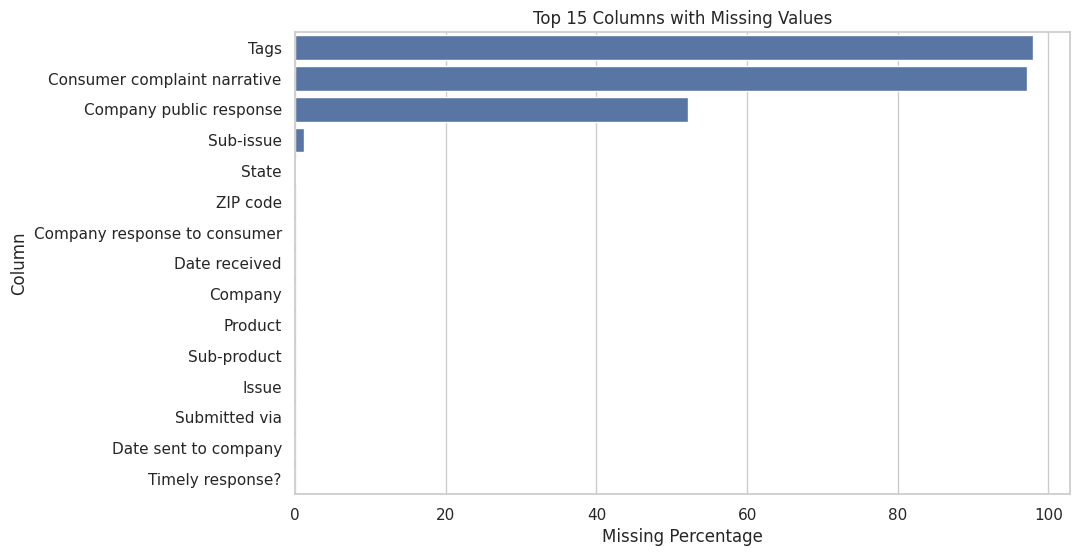

In [7]:
# Visualise missing values
plt.figure(figsize=(10,6))

sns.barplot(
    data=missing_values.head(15),
    x='Missing Percentage',
    y='Column'
)

plt.title('Top 15 Columns with Missing Values')
plt.show()

### Insights

* The dataset contains 3.44 million complaints submitted between December 2025 and June 2026.
* Complaints cover 3,254 companies, 11 financial products, and 90 issue categories.
* Most fields are complete and suitable for analysis.
* Consumer complaint narratives are only available for a small subset of complaints and will be used separately for NLP modelling.

## 📊 Exploratory Data Analysis

### Complaint Volume Analysis

In [8]:
# Number of complaints
print(f'Total Complaints: {len(df):,}')

# Unique companies
print(f'Unique Companies: {df["Company"].nunique():,}')

# Unique products
print(f'Unique Products: {df["Product"].nunique():,}')

# Unique issues
print(f'Unique Issues: {df["Issue"].nunique():,}')

Total Complaints: 3,435,183
Unique Companies: 3,254
Unique Products: 11
Unique Issues: 90


### Product Analysis

In [9]:
# Top complaint products
product_counts = (
    df['Product']
    .value_counts()
    .head(15)
)

product_counts

Product
Credit reporting or other personal consumer reports        3113062
Debt collection                                             166028
Credit card                                                  45710
Checking or savings account                                  41485
Money transfer, virtual currency, or money service           17960
Mortgage                                                     15421
Vehicle loan or lease                                        12091
Student loan                                                 10258
Payday loan, title loan, personal loan, or advance loan       8187
Prepaid card                                                  2886
Debt or credit management                                     2095
Name: count, dtype: int64

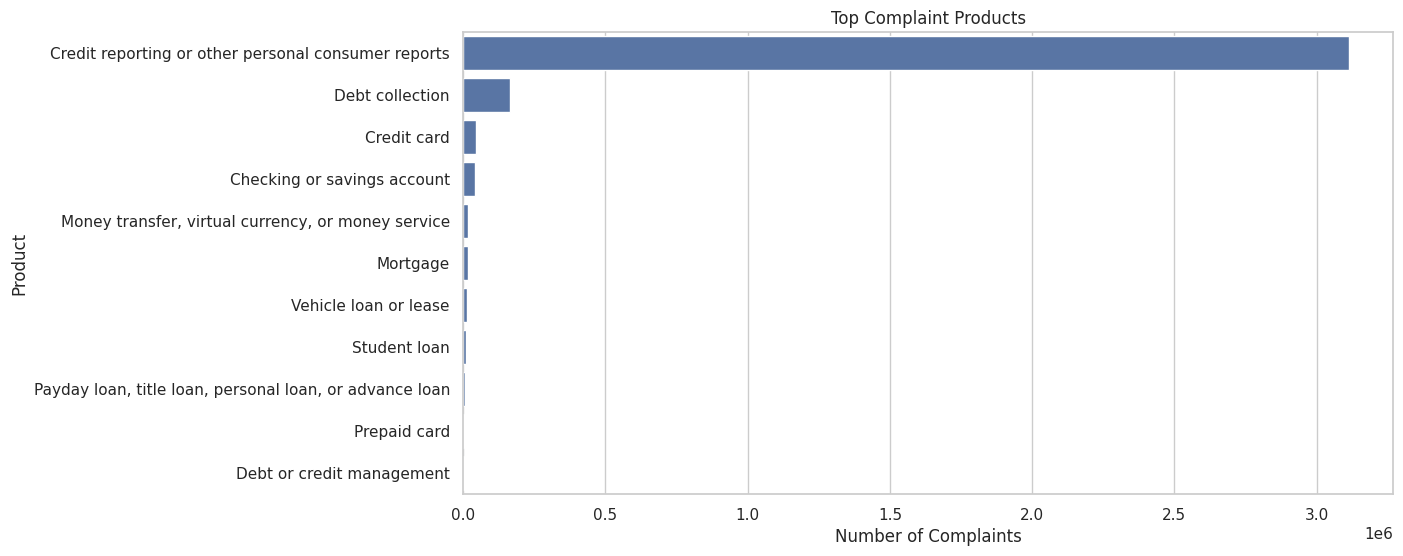

In [10]:
# Visualise complaint products
plt.figure(figsize=(12,6))

sns.barplot(
    x=product_counts.values,
    y=product_counts.index
)

plt.title('Top Complaint Products')
plt.xlabel('Number of Complaints')
plt.ylabel('Product')

plt.show()

In [11]:
# Product percentage distribution
product_percentage = (
    df['Product']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

product_percentage

Product
Credit reporting or other personal consumer reports        90.62
Debt collection                                             4.83
Credit card                                                 1.33
Checking or savings account                                 1.21
Money transfer, virtual currency, or money service          0.52
Mortgage                                                    0.45
Vehicle loan or lease                                       0.35
Student loan                                                0.30
Payday loan, title loan, personal loan, or advance loan     0.24
Prepaid card                                                0.08
Debt or credit management                                   0.06
Name: proportion, dtype: float64

### Insights

Credit reporting and personal consumer reports account for more than 90% of all complaints in the dataset. This level of concentration indicates that consumer reporting remains the dominant source of customer dissatisfaction during the analysis period.

Debt collection is the second-largest complaint category, although its volume is substantially lower. The remaining products each contribute only a small share of total complaints, highlighting the overwhelming influence of credit reporting-related issues.

### Issue Analysis

In [12]:
# Top complaint issues
issue_counts = (
    df['Issue']
    .value_counts()
    .head(15)
)

issue_counts

Issue
Incorrect information on your report                               1848292
Improper use of your report                                         677347
Problem with a company's investigation into an existing problem     572966
Attempts to collect debt not owed                                    73666
Took or threatened to take negative or legal action                  42776
Written notification about debt                                      25048
Managing an account                                                  24048
False statements or representation                                   16786
Problem with a purchase shown on your statement                      15139
Problem with fraud alerts or security freezes                        11203
Unable to get your credit report or credit score                      9026
Trouble during payment process                                        7519
Problem with a lender or other company charging your account          6060
Dealing with your l

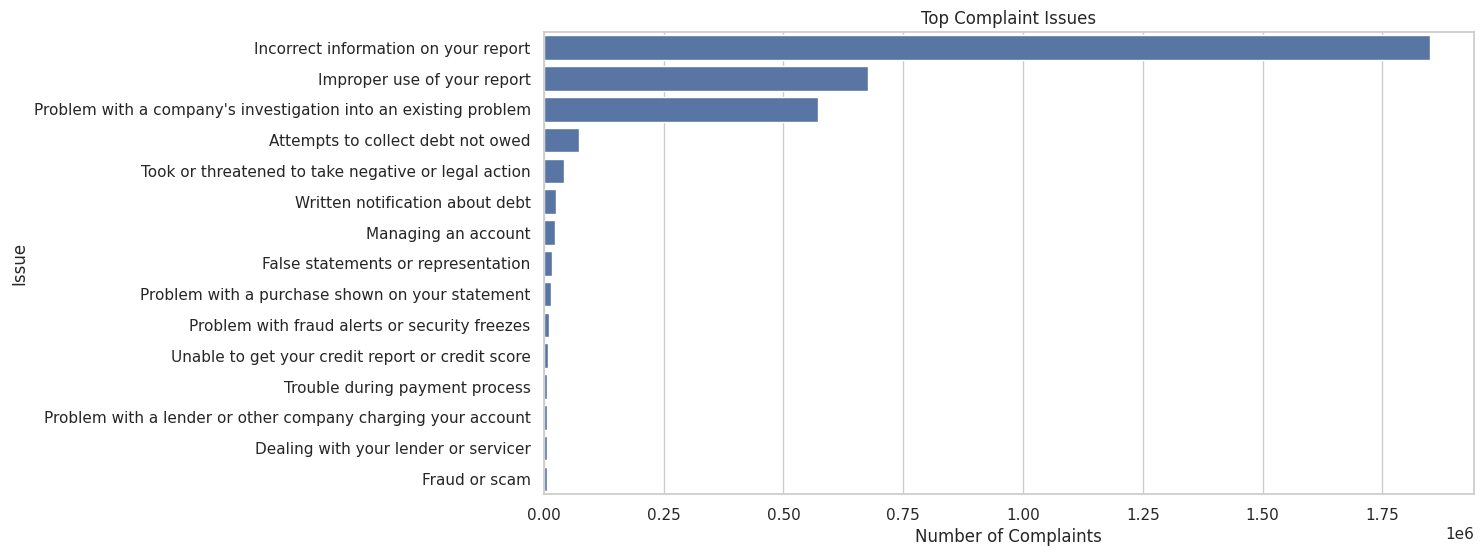

In [13]:
# Visualise complaint issues
plt.figure(figsize=(12,6))

sns.barplot(
    x=issue_counts.values,
    y=issue_counts.index
)

plt.title('Top Complaint Issues')
plt.xlabel('Number of Complaints')
plt.ylabel('Issue')

plt.show()

### Insights

The most common complaint issue is incorrect information on consumer reports, followed by improper use of reports and problems with dispute investigations. Together, these categories account for a large proportion of all complaints.

The results suggest that data accuracy, dispute resolution, and credit reporting practices are the primary drivers of customer dissatisfaction. These areas are likely to generate the most valuable business insights throughout the project.

### Company Analysis

In [14]:
# Top companies
company_counts = (
    df['Company']
    .value_counts()
    .head(15)
)

company_counts

Company
TRANSUNION INTERMEDIATE HOLDINGS, INC.    1152431
Experian Information Solutions Inc.        937574
EQUIFAX, INC.                              915779
LEXISNEXIS                                  17305
CAPITAL ONE FINANCIAL CORPORATION           16226
CL Holdings LLC                             15591
CBC Companies, Inc.                         15398
JPMORGAN CHASE & CO.                        12995
Resurgent Capital Services L.P.             12140
ENCORE CAPITAL GROUP INC.                   12111
BANK OF AMERICA, NATIONAL ASSOCIATION       12104
WELLS FARGO & COMPANY                       11762
CITIBANK, N.A.                              11439
Portfolio Recovery Associates, LLC          11031
SYNCHRONY FINANCIAL                          8389
Name: count, dtype: int64

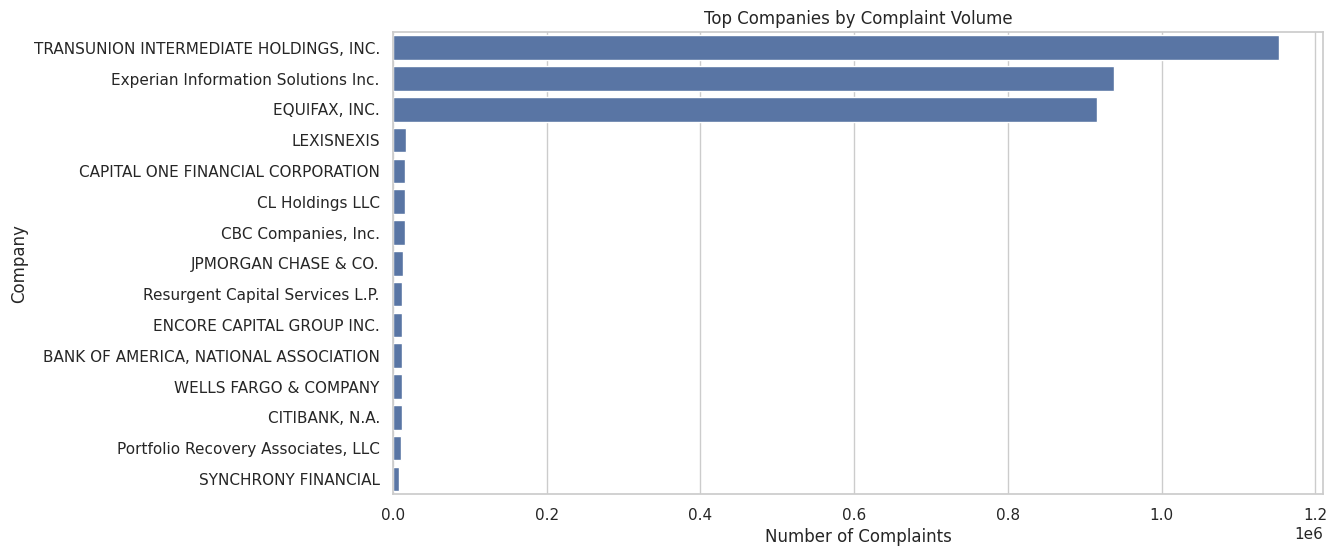

In [15]:
# Visualise companies
plt.figure(figsize=(12,6))

sns.barplot(
    x=company_counts.values,
    y=company_counts.index
)

plt.title('Top Companies by Complaint Volume')
plt.xlabel('Number of Complaints')
plt.ylabel('Company')

plt.show()

### Insights

TransUnion, Experian, and Equifax receive the highest complaint volumes by a considerable margin. This finding is consistent with the earlier product and issue analyses, which showed that credit reporting dominates the dataset.

The concentration of complaints among a small number of companies creates an opportunity to analyse recurring pain points, emerging trends, and operational risks at the company level.

### Complaint Trend Analysis

In [16]:
# Convert date column
df['Date received'] = pd.to_datetime(df['Date received'], utc=True)

In [17]:
# Weekly complaints
weekly_complaints = (
    df
    .set_index('Date received')
    .resample('W')
    .size()
)

weekly_complaints

Date received
2025-12-21 00:00:00+00:00    101774
2025-12-28 00:00:00+00:00     90682
2026-01-04 00:00:00+00:00     92606
2026-01-11 00:00:00+00:00    133139
2026-01-18 00:00:00+00:00    127356
2026-01-25 00:00:00+00:00    121149
2026-02-01 00:00:00+00:00    121309
2026-02-08 00:00:00+00:00    122992
2026-02-15 00:00:00+00:00    120269
2026-02-22 00:00:00+00:00    123583
2026-03-01 00:00:00+00:00    130783
2026-03-08 00:00:00+00:00    136806
2026-03-15 00:00:00+00:00    140856
2026-03-22 00:00:00+00:00    142531
2026-03-29 00:00:00+00:00    141541
2026-04-05 00:00:00+00:00    136466
2026-04-12 00:00:00+00:00    145161
2026-04-19 00:00:00+00:00    140992
2026-04-26 00:00:00+00:00    147813
2026-05-03 00:00:00+00:00    150744
2026-05-10 00:00:00+00:00    153334
2026-05-17 00:00:00+00:00    156742
2026-05-24 00:00:00+00:00    154974
2026-05-31 00:00:00+00:00    153997
2026-06-07 00:00:00+00:00    143329
2026-06-14 00:00:00+00:00    103640
2026-06-21 00:00:00+00:00       615
Freq: W-SUN, d

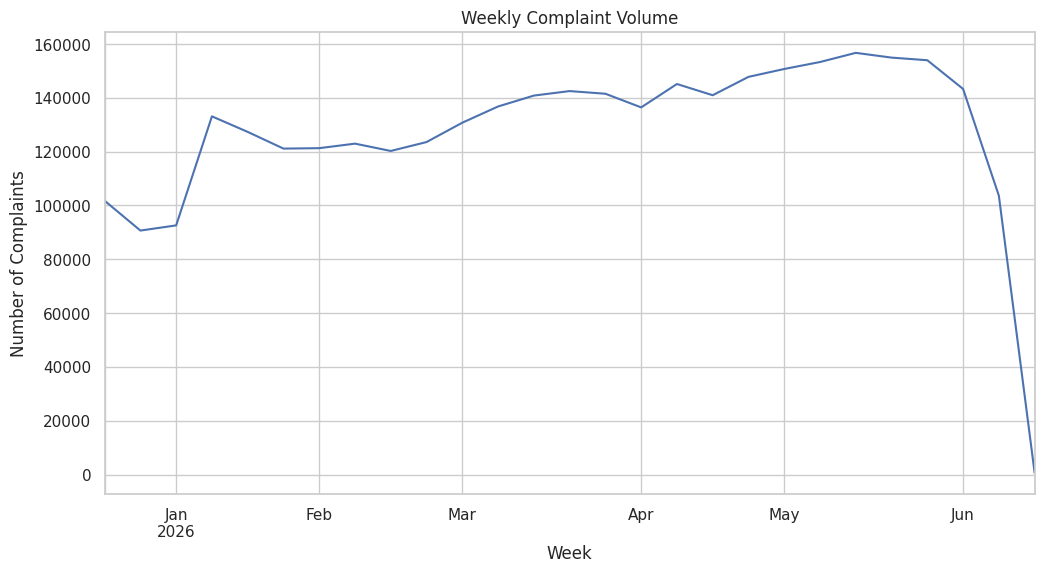

In [18]:
# Plot complaint trends
plt.figure(figsize=(12,6))

weekly_complaints.plot()

plt.title('Weekly Complaint Volume')
plt.xlabel('Week')
plt.ylabel('Number of Complaints')

plt.show()

In [19]:
# Remove incomplete final week
weekly_complaints_clean = weekly_complaints.iloc[:-1]

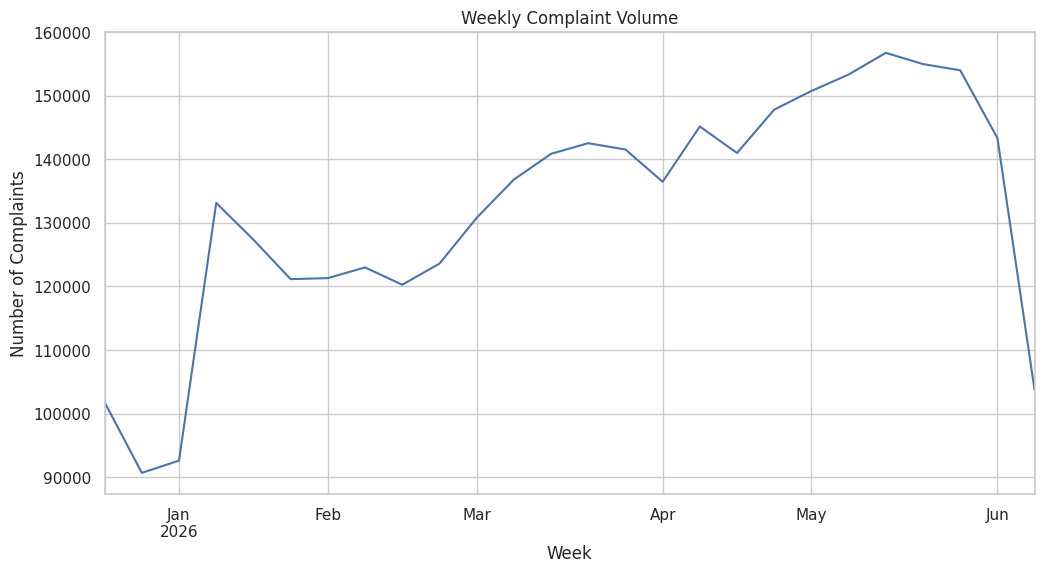

In [20]:
# Plot weekly complaint trend
plt.figure(figsize=(12,6))

weekly_complaints_clean.plot()

plt.title('Weekly Complaint Volume')
plt.xlabel('Week')
plt.ylabel('Number of Complaints')

plt.show()

### Insights

Weekly complaint volume increased steadily throughout the analysis period, reaching its highest levels during May 2026. This upward trend may indicate growing customer dissatisfaction, increased reporting activity, or both.

The final week should not be interpreted as a genuine decline because the dataset ends on 16 June 2026, resulting in an incomplete reporting period.

### Complaint Narrative Exploration

In [21]:
# Narrative availability
narrative_percentage = (
    df['Consumer complaint narrative']
    .notnull()
    .mean()
    * 100
)

print(f'Narrative Availability: {narrative_percentage:.2f}%')

Narrative Availability: 2.85%


In [22]:
# Create NLP dataset
df_nlp = df[df['Consumer complaint narrative'].notnull()].copy()

print(f'NLP Dataset Shape: {df_nlp.shape}')

NLP Dataset Shape: (97945, 16)


In [23]:
# Calculate complaint length
df_nlp['Narrative Length'] = (
    df_nlp['Consumer complaint narrative']
    .str.split()
    .str.len()
)

df_nlp['Narrative Length'].describe()

count    97945.000000
mean       205.845954
std        207.937396
min          5.000000
25%         80.000000
50%        157.000000
75%        264.000000
max       5205.000000
Name: Narrative Length, dtype: float64

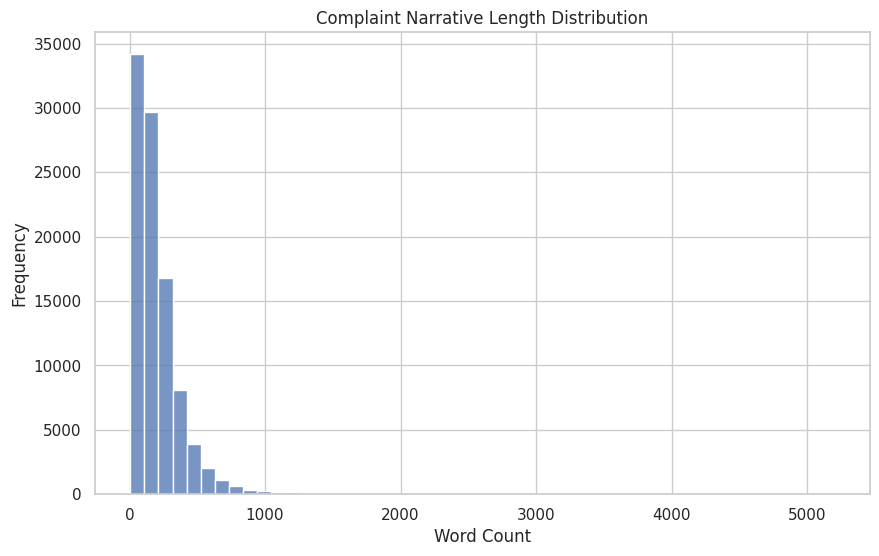

In [24]:
# Plot narrative length distribution
plt.figure(figsize=(10,6))

sns.histplot(
    df_nlp['Narrative Length'],
    bins=50
)

plt.title('Complaint Narrative Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.show()

In [25]:
# Sample narratives
df['Consumer complaint narrative'].dropna().sample(5, random_state=42)

583621     At the end of XX/XX/XXXX, I requested a new AAA card from Comenity Capital Bank aka Bread Financial as I misplaced the card. I never received a new card. As i used a store credit card from the same bank in early XXXX that was declined I discovered XXXX left a message on line regarding fraud was ...
56705      My husband and I applied for credit thru XXXXXXXX XXXX XXXX XXXX to obtain a XXXX XXXX. It was approved thru Wells Fargo. Document received by us for signature. Only my husband signed as was told both signatures were not necessary. My husband had to file chapter XXXX bankruptcy XX/XX/year>. Once...
3334218    I used to go to XXXX XXXX on XXXX XXXX  and I then called and canceled my membership but they did not cancel it and have continued to keep calling me and saying I needed to pay my membership even though I no longer work out there or even have gone in a couple months. I recently got a text from A...
2916417    On XX/XX/XXXX I withdrew XXXX an tried to send it to my 

### Insights

Although only 2.85% of complaints contain consumer-written narratives, the NLP dataset still includes nearly 98,000 records. This provides a sufficiently large sample for sentiment analysis, topic modelling, classification, and explainability.

Complaint narratives are generally detailed, with an average length of approximately 200 words. The combination of narrative depth and dataset size creates a strong foundation for downstream NLP tasks.

### Common Words

In [26]:
# Import stopwords
import nltk

# Download stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [27]:
# Import NLP libraries
import re

from collections import Counter
from nltk.corpus import stopwords

In [28]:
# Create stopword list
stop_words = set(stopwords.words('english'))

In [29]:
# Combine complaint text
text = ' '.join(
    df_nlp['Consumer complaint narrative']
    .fillna('')
    .astype(str)
)

In [30]:
# Clean text
text = re.sub(r'[^a-zA-Z\s]', ' ', text)

words = [
    word.lower()
    for word in text.split()
    if word.lower() not in stop_words
    and len(word) > 2
]

In [31]:
# Get common words
common_words = Counter(words).most_common(20)

common_words

[('xxxx', 1016310),
 ('account', 203579),
 ('credit', 167195),
 ('reporting', 95159),
 ('debt', 83856),
 ('information', 79626),
 ('report', 68277),
 ('payment', 64886),
 ('bank', 53264),
 ('dispute', 51780),
 ('consumer', 47669),
 ('balance', 45277),
 ('accounts', 43514),
 ('provide', 43127),
 ('year', 43120),
 ('card', 42933),
 ('collection', 41828),
 ('request', 40296),
 ('documentation', 37512),
 ('act', 36935)]

In [32]:
# Add custom stopwords
custom_stopwords = {
    'xxxx',
    'xx',
    'xxx',
    'xxxxxxxx',
    'xxxxxxxxxx'
}

stop_words.update(custom_stopwords)

In [33]:
# Rerun to get common words

text = re.sub(r'[^a-zA-Z\s]', ' ', text)

words = [
    word.lower()
    for word in text.split()
    if word.lower() not in stop_words
    and len(word) > 2
]

common_words = Counter(words).most_common(20)

common_words

[('account', 203579),
 ('credit', 167195),
 ('reporting', 95159),
 ('debt', 83856),
 ('information', 79626),
 ('report', 68277),
 ('payment', 64886),
 ('bank', 53264),
 ('dispute', 51780),
 ('consumer', 47669),
 ('balance', 45277),
 ('accounts', 43514),
 ('provide', 43127),
 ('year', 43120),
 ('card', 42933),
 ('collection', 41828),
 ('request', 40296),
 ('documentation', 37512),
 ('act', 36935),
 ('complaint', 36797)]

In [34]:
# Convert to dataframe
common_words_df = pd.DataFrame(
    common_words,
    columns=['Word', 'Count']
)

common_words_df

,Word,Count
0,account,203579
1,credit,167195
2,reporting,95159
3,debt,83856
4,information,79626
5,report,68277
6,payment,64886
7,bank,53264
8,dispute,51780
9,consumer,47669


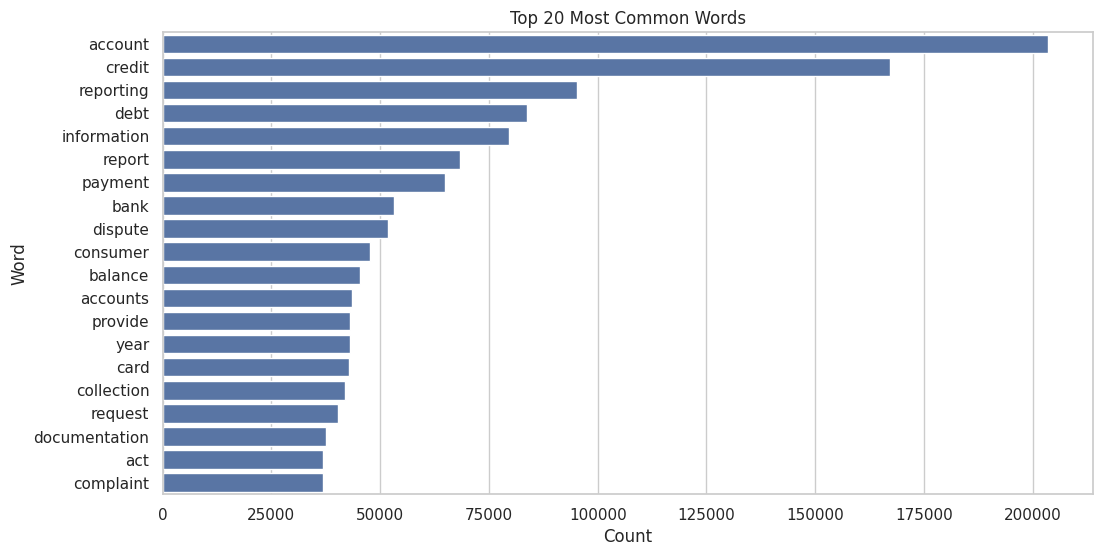

In [35]:
# Plot common words
plt.figure(figsize=(12,6))

sns.barplot(
    data=common_words_df,
    x='Count',
    y='Word'
)

plt.title('Top 20 Most Common Words')
plt.show()

### Common Bigrams

In [36]:
# Import bigram tools
from nltk.util import ngrams

In [37]:
# Generate bigrams
bigrams = list(ngrams(words, 2))

bigram_counts = Counter(bigrams).most_common(20)

In [38]:
# Convert to dataframe
bigram_df = pd.DataFrame(
    bigram_counts,
    columns=['Bigram', 'Count']
)

bigram_df['Bigram'] = bigram_df['Bigram'].apply(
    lambda x: ' '.join(x)
)

bigram_df

,Bigram,Count
0,credit reporting,35168
1,credit report,30208
2,fair credit,21776
3,reporting act,16599
4,identity theft,15389
5,credit card,14939
6,account number,12693
7,wells fargo,12192
8,debt collection,11199
9,reporting agencies,10934


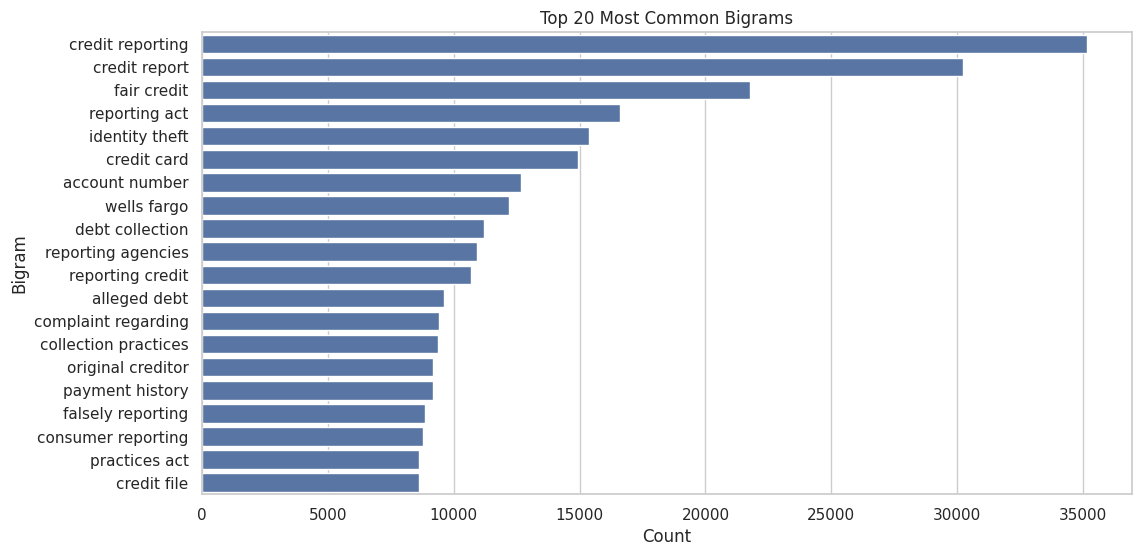

In [39]:
# Plot bigrams
plt.figure(figsize=(12,6))

sns.barplot(
    data=bigram_df,
    x='Count',
    y='Bigram'
)

plt.title('Top 20 Most Common Bigrams')

plt.show()

### Insights

The most frequently used words and phrases revolve around accounts, credit reporting, debt, disputes, and payment-related issues. This aligns closely with the dominant complaint categories identified during exploratory analysis.

Common bigrams such as *credit reporting*, *credit report*, *identity theft*, and *debt collection* reveal recurring customer concerns involving report accuracy, regulatory compliance, fraud, and collection activities. These themes are likely to emerge again during topic modelling and pain point discovery.

## 💡 Initial Business Insights

* Credit reporting complaints dominate both structured complaint records and complaint narratives.
* Incorrect credit information and dispute investigation issues represent the largest customer pain points.
* Complaint volumes increased steadily throughout the analysis period.
* Consumer narratives provide sufficient detail for NLP modelling despite low overall availability.
* The dataset contains strong signals for future:
    * Sentiment analysis
    * Topic modelling
    * Complaint category prediction
    * Urgency scoring
    * Escalation prediction

## 🧹 Text Cleaning & Preprocessing

In [40]:
# Clean complaint text
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [41]:
# Clean complaint narratives
df_nlp['cleaned_narrative'] = (
    df_nlp['Consumer complaint narrative']
    .apply(clean_text)
)

In [42]:
# Compare original and cleaned text
sample_idx = 0

print('Original:')
print(df_nlp['Consumer complaint narrative'].iloc[sample_idx])

print('\nCleaned:')
print(df_nlp['cleaned_narrative'].iloc[sample_idx])

Original:
In XXXX, while shopping at Best Buy, the store employee told me the My Best Buy Credit Card offered 2 years interest-free and that interest would only start after the 24-month promotional period. I clearly understood that I could make minimum monthly payments during those 2 years, and that only after 24 months would interest begin to be charged on whatever balance remained at that time. I was never told either verbally or in writing that if I didnt pay the full amount by the end of the 24 months, Citibank would retroactively charge interest all the way back to the original XXXX purchase date.I made consistent good-faith payments and successfully reduced the original promotional balance of approximately {$4600.00} down to around {$900.00} by the end of XXXX. However, in XX/XX/XXXX, Citibank suddenly added {$1700.00} in deferred ( retroactive ) interest dating back to XXXX. This came as a complete surprise.I lived in XXXX from XXXX until XX/XX/XXXX. Although I could sometimes a

In [43]:
# Calculate cleaned text length
df_nlp['cleaned_word_count'] = (
    df_nlp['cleaned_narrative']
    .str.split()
    .str.len()
)

df_nlp['cleaned_word_count'].describe()

count    97945.000000
mean       201.835694
std        201.559367
min          5.000000
25%         79.000000
50%        153.000000
75%        259.000000
max       5154.000000
Name: cleaned_word_count, dtype: float64

### Insights

- Text cleaning successfully standardised complaint narratives by removing special characters, punctuation, and formatting inconsistencies.
- The average complaint length remained largely unchanged after cleaning, indicating that most narrative content was preserved.
- The cleaned narratives are suitable for sentiment analysis, topic modelling, and machine learning tasks.

## 😊 Sentiment Analysis

In [44]:
# Download VADER lexicon
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [45]:
# Import sentiment analyzer
from nltk.sentiment import SentimentIntensityAnalyzer

In [46]:
# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

In [47]:
# Calculate sentiment score
df_nlp['sentiment_score'] = (
    df_nlp['cleaned_narrative']
    .apply(lambda x: sia.polarity_scores(x)['compound'])
)

In [48]:
# Categorize sentiment
def classify_sentiment(score):

    if score >= 0.05:
        return 'Positive'

    elif score <= -0.05:
        return 'Negative'

    else:
        return 'Neutral'

In [49]:
# Create sentiment category
df_nlp['sentiment_category'] = (
    df_nlp['sentiment_score']
    .apply(classify_sentiment)
)

In [50]:
# Sentiment distribution
sentiment_counts = (
    df_nlp['sentiment_category']
    .value_counts()
)

sentiment_counts

sentiment_category
Negative    56270
Positive    38022
Neutral      3653
Name: count, dtype: int64

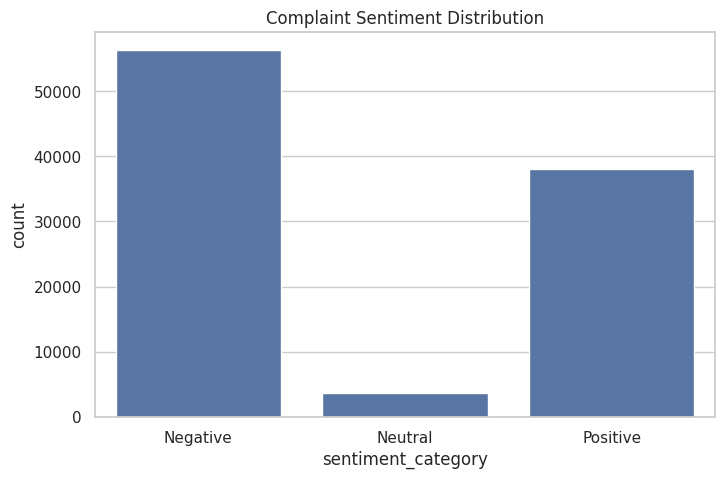

In [51]:
# Plot sentiment distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_nlp,
    x='sentiment_category',
    order=['Negative', 'Neutral', 'Positive']
)

plt.title('Complaint Sentiment Distribution')

plt.show()

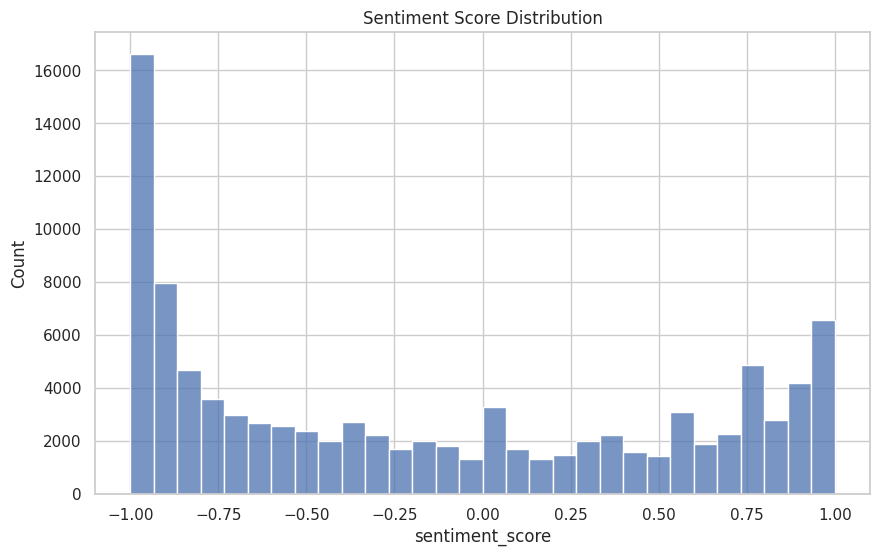

In [52]:
# Plot sentiment scores
plt.figure(figsize=(10,6))

sns.histplot(
    df_nlp['sentiment_score'],
    bins=30
)

plt.title('Sentiment Score Distribution')

plt.show()

In [53]:
# Most negative complaints
df_nlp.sort_values(
    by='sentiment_score'
).head(5)[
    ['sentiment_score', 'Consumer complaint narrative']
]

,sentiment_score,Consumer complaint narrative
1350414,-0.9999,"b""Deposition By XXXX XXXX XXXX on XXXX \n On the XXXX day of XXXX of XXXX, I was using my debit card XXXX to purchase items on the internet. I was trying to add funds to my XXXX account to print off the rest of my stamp ..."
215663,-0.9999,"I am formally requesting that the Consumer Financial Protection Bureau ( CFPB ) immediately enforce corrective action against Equifax, Experian, and TransUnion for persistent and repeated violations of federal law. Over 30 days ago, I submitted detailed written disputes, comprehensive identity t..."
1558122,-0.9999,I. BORROWER INFORMATION Name : XXXX XXXX ( legal name ) / XXXX XXXX ( former name on account ) Account Number : XXXX Loan Type : Federal Direct Unsubsidized Loan Original Principal : {$9200.00} Previous Servicer : XXXX Current Servicer : XXXX XXXX XXXX XXXX ( XXXX ) Transfer Date : XX/XX/XXXX Da...
632581,-0.9999,"I am formally requesting that the Consumer Financial Protection Bureau ( CFPB ) immediately enforce corrective action against XXXX and LexisNexis for persistent and repeated violations of federal law. Over 30 days ago, I submitted detailed written disputes, comprehensive identity theft documenta..."
215667,-0.9999,"I am formally requesting that the Consumer Financial Protection Bureau ( CFPB ) immediately enforce corrective action against Equifax, Experian, and TransUnion for persistent and repeated violations of federal law. Over 30 days ago, I submitted detailed written disputes, comprehensive identity t..."


In [54]:
# Most positive complaints
df_nlp.sort_values(
    by='sentiment_score',
    ascending=False
).head(5)[
    ['sentiment_score', 'Consumer complaint narrative']
]

,sentiment_score,Consumer complaint narrative
245055,0.9998,I am filing this complaint regarding serious violations of federal consumer protection statutes by Freedom Mortgage Corporation in connection with their servicing of my mortgage loan and their filing of a foreclosure action despite lacking standing and despite failing to comply with federal law....
2869991,0.9998,"I have attempted to resolve this with the support representatives, whom stated multiple times someone would call me but over two days no one ever called me. it was always myself calling them. they continued misinforming me about the case. Here is a letter I typed out and the chat transcripts. bu..."
830854,0.9998,"Bilt is transition from XXXX XXXX to an unknown bank and the rollout has been a mess. But they have so far also not honored what they were advertising as per below copies of their website. They clearly noted that this new "" BiltCash '' will be automatically credited upon opening of account. I wa..."
302931,0.9997,XXXX XXXX and XXXX XXXX in Mortgage Tax Servicing : The CoreLogic-BAC Nexus Executive Summary : Strategic Context and Definitive Findings The structural transformation of the United States mortgage servicing landscape over the past XXXX decades is epitomized by the strategic nexus formed betwee...
2954393,0.9997,"Request to move withdrawal from XX/XX/XXXX to XX/XX/XXXX. Company confirmed receipt of request that was made within the appropriate time. Draft took place anyway and resulted in {$98.00} in overdraft fees which ClearOne agreed to pay, but has not refunded the money to my account. Please see copy..."


### Insights

Most complaint narratives were classified as negative, which is expected given the nature of consumer complaints. However, manual review revealed that sentiment scores do not always reflect the true severity or business impact of a complaint.

Many highly detailed regulatory or legal complaints received extremely positive or negative scores despite describing similar levels of customer harm. For this reason, sentiment should be treated as a supplementary signal rather than a direct measure of urgency.

## 🚨 Severity Analysis

In [55]:
# Define severity keywords
severity_keywords = [
    'fraud',
    'identity theft',
    'lawsuit',
    'legal action',
    'foreclosure',
    'bankruptcy',
    'scam',
    'harassment',
    'unauthorized',
    'stolen',
    'discrimination',
    'financial hardship',
    'hardship',
    'victim',
    'damages',
    'violation',
    'violations',
    'refused',
    'refusal',
    'closed account',
    'account closure',
    'identity',
    'theft',
    'unauthorized transaction',
    'locked account',
    'restricted account',
    'foreclosure',
    'repossession',
    'eviction',
    'overdraft',
    'charge off',
    'charge-off'
]

In [56]:
# Calculate severity score
def calculate_severity(text):

    text = str(text).lower()

    score = sum(
        keyword in text
        for keyword in severity_keywords
    )

    return score

In [57]:
# Create severity score
df_nlp['severity_score'] = (
    df_nlp['cleaned_narrative']
    .apply(calculate_severity)
)

In [58]:
# Categorize severity
def classify_severity(score):

    if score >= 4:
        return 'High'

    elif score >= 2:
        return 'Medium'

    else:
        return 'Low'

In [59]:
# Create severity category
df_nlp['severity_category'] = (
    df_nlp['severity_score']
    .apply(classify_severity)
)

In [60]:
# Severity distribution
severity_counts = (
    df_nlp['severity_category']
    .value_counts()
)

severity_counts

severity_category
Low       70218
Medium    18073
High       9654
Name: count, dtype: int64

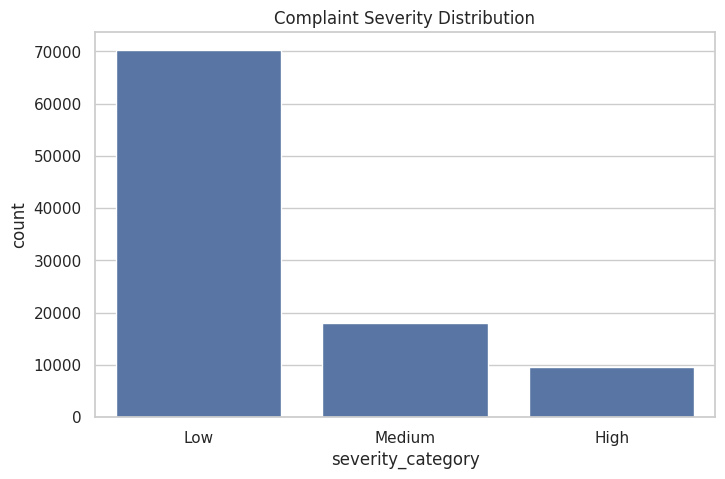

In [61]:
# Plot severity distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_nlp,
    x='severity_category',
    order=['Low', 'Medium', 'High']
)

plt.title('Complaint Severity Distribution')

plt.show()

In [62]:
# High severity examples
df_nlp.loc[
    df_nlp['severity_category'] == 'High',
    [
        'severity_score',
        'Consumer complaint narrative'
    ]
].head(5)

,severity_score,Consumer complaint narrative
271,4,"I am resubmitting this complaint because I am not satisfied with Citis response, and the issue remains unresolved. My account is still restricted, and I am unable to use my credit card.\n\nCitis response did not adequately address the hardship, lack of communication, or conflicting information I..."
1575,6,I am re-filing this complaint because Wells Fargos XX/XX/XXXX response stated that my prior complaint was being closed because I had not submitted the retail installment sales contract and all service-contract documents. I am now attaching the exact documents Wells Fargo said were required. \n\n...
1586,4,"The collection agency ( FCO ) is actively reporting and attempting to collect a fabricated debt of {$1300.00}, despite their own agent verbally admitting on a recorded line that the original creditor has no grounds to pursue the collection. Furthermore, the original creditor is using the collect..."
1594,6,"To Wells Fargo Executive Resolution Team and Consumer Financial Protection Bureau : I am filing a formal complaint regarding the wrongful handling of my account, improper fee assessments, and closure of my banking services while active disputes were still unresolved.\n\nFor approximately two mon..."
2845,4,"I am filing a complaint against U.S. Bank regarding a fraudulent {$2500.00} check associated with my account and Altitude Reserve credit card ( Case # XXXX ). \n\nThis check was stolen from my mail and fraudulently cashed. I did not authorize, sign, or benefit from this transaction in any way. \..."


### Insights

Most complaints were classified as low severity, indicating that severe risk indicators appear in a minority of narratives. Nevertheless, nearly 10,000 complaints were identified as high severity, representing a meaningful group of cases that may require additional review.

High-severity complaints frequently involve fraud, unauthorized activity, financial hardship, account restrictions, debt disputes, and regulatory violations. Compared with sentiment analysis, severity scoring appears to align more closely with potential business impact and escalation risk.

## 💡 Sentiment & Severity Insights

The sentiment analysis results confirm that most complaint narratives express negative customer experiences. However, manual review showed that sentiment scores do not always reflect the true severity or operational impact of a complaint. Formal regulatory language, detailed dispute records, and legal terminology can sometimes produce misleading sentiment classifications.

Severity scoring provided a more practical view of business risk by highlighting complaints involving fraud, unauthorized activity, financial hardship, account restrictions, and regulatory violations. As a result, severity appears to be a stronger candidate for future urgency scoring and escalation decision support.

Together, sentiment and severity features provide complementary perspectives on customer complaints. Sentiment captures emotional tone, while severity focuses on potential business impact. Both will be explored further in later modelling and decision-support components of ComplaintIQ.